<div align='center'>
<h1 style='font-size:42px;'>Grain Optical Efficiencies</h1>
<h2 style='font-weight:400;'>Computing <code>Q_abs</code> and <code>Q_sca</code> with <code>pyGrater</code></h2>
<p><em>A concise guide to absorption & scattering efficiency tables</em></p>
</div>

---

**This tutorial covers:**
- Creating a Grain type and calculating/loading optical efficiencies
- Visualizing Q 
- Understanding and editing `parameters/general.yaml`
- Recomputing efficiency tables after parameter changes

## 1. Setup
We import the key utilities and create a `Grain` instance. By default, the code loads precomputed efficiency tables (unless `redo_Q=True`).

In [ ]:
from pyGrater import Grain, Star 
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import yaml

INFO - Logging to file: /Users/prioletp/PhD/public_codes/pyGrater/logs/pyGrater_20260623_172814.log (logging_config.py:line 152)


CREATING GRAIN OBJECT
Developper parameters file: /Users/prioletp/PhD/public_codes/pyGrater/pyGrater/parameters/developper_params.yaml
Grain composition: astroSi
astroSi optical tables already exist :
--> Wavelengths : 1000 values from 5.0e-02 to 2.0e+03 microns
--> Sizes : 600 values from 1.0e-02 to 3.0e+03 microns
Developper parameters YAML path: /Users/prioletp/PhD/public_codes/pyGrater/pyGrater/parameters/developper_params.yaml

Developper parameters loaded:
 - size_min: 0.0099999999
 - size_max: 1000.0000001
 - waves_min: 0.04008001
 - waves_max: 1980
 - N_sizes: 600
 - N_waves: 1000
 - N_waves_undersampled: 1000

Current composition: astroSi


When initializing the grain you can specify the composition with the keyword `composition='comp_name'`

In [2]:
# Instantiate a Grain. Set redo_Q=True to force recalculation of efficiencies.
grain = Grain(redo_Q=False, composition='astroSi')  # Define a grain object

# Quick peek at arrays
Q_abs = grain.Qabs          # shape: (n_sizes, n_waves)
Q_sca = grain.Qsca          # shape: (n_sizes, n_waves)
sizes = grain.Qabs_sizes    # in microns
waves = grain.Qabs_waves    # in microns



In [3]:
grain.grain_properties

{'Nickname': 'astroSi',
 'Wav_min': 6.1992e-05,
 'Wav_max': 123984.0,
 'Tsub': 1500.0,
 'Density': 3.5,
 'File_par': 'astroSi.txt',
 'File_per1': 'astroSi.txt',
 'File_per2': 'astroSi.txt',
 'Weight_par': 0.333333,
 'Weight_per1': 0.333333,
 'Weight_per2': 0.333333,
 'Full_Name': 'Smoothed UV Astronomical Silicate',
 'Formula': '',
 'Class': '',
 'Subclass': '',
 'Group': 'Silicates',
 'Reference': 'Draine, B.~T.\\ 2003, ApJ, 598, 1026',
 'Web': 'http://www.astro.princeton.edu/~draine/dust/dust.diel.html'}

## 2. Developper parameters (parameters/developper_params.yaml)
The general controls for grid resolution and ranges are stored in `parameters/developper_params.yaml`. Key fields typically include:
- `composition`: which material to use (must exist in `data/material_list.txt`)
- `N_sizes`, `size_min`, `size_max`: number of grain sizes and range (µm)
- `N_waves`, `N_waves_undersampled`, `waves_min`, `waves_max`: wavelength sampling (µm)

You can inspect them from the `Grain` instance and edit the YAML file to adjust resolution and ranges.

In [4]:
print("Developper parameters YAML path:", grain.developper_params_path)
with open(grain.developper_params_path, 'r') as f:
    developper_params = yaml.load(f, Loader=yaml.FullLoader)

print("\nDevelopper parameters loaded:")
for k, v in developper_params.items():
    print(f" - {k}: {v}")

print("\nCurrent composition:", grain.grain_composition_name)

Tip:
- After editing `developper_params.yaml` (e.g., changing `N_sizes` or `waves_max`), recreate the `Grain` with `redo_Q=True` to regenerate the efficiency tables:
```python
grain = stgr.Grain(redo_Q=True)
```
This will recompute Q_abs and Q_sca and write them to the `efficiencies/` folder.

## 3. Quick 1D inspections
Plot Q vs wavelength for a selected size, and Q vs size for a selected wavelength.

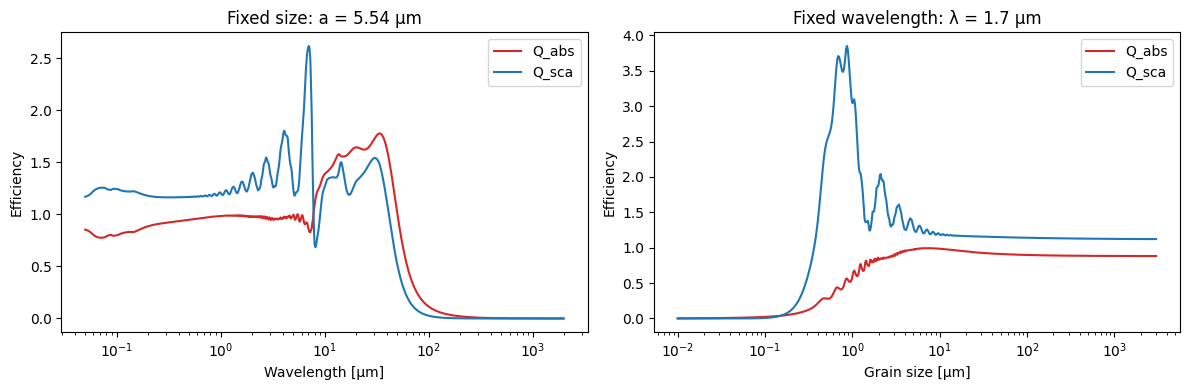

In [5]:
# Pick indices roughly in the middle of the arrays
i_size = len(sizes)//2
i_wave = len(waves)//3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

# Q vs wavelength at a fixed size
ax1.semilogx(waves, Q_abs[i_size,:], label='Q_abs', c='tab:red')
ax1.semilogx(waves, Q_sca[i_size,:], label='Q_sca', c='tab:blue')
ax1.set_xlabel('Wavelength [µm]')
ax1.set_ylabel('Efficiency')
ax1.set_title(f'Fixed size: a = {sizes[i_size]:.3g} µm')
ax1.legend()

# Q vs size at a fixed wavelength
ax2.semilogx(sizes, Q_abs[:,i_wave], label='Q_abs', c='tab:red')
ax2.semilogx(sizes, Q_sca[:,i_wave], label='Q_sca', c='tab:blue')
ax2.set_xlabel('Grain size [µm]')
ax2.set_ylabel('Efficiency')
ax2.set_title(f'Fixed wavelength: λ = {waves[i_wave]:.3g} µm')
ax2.legend()
plt.tight_layout()

## 4. 2D maps of Q_abs and Q_sca
Visualize both efficiencies as functions of wavelength and grain size (log-scaled axes).

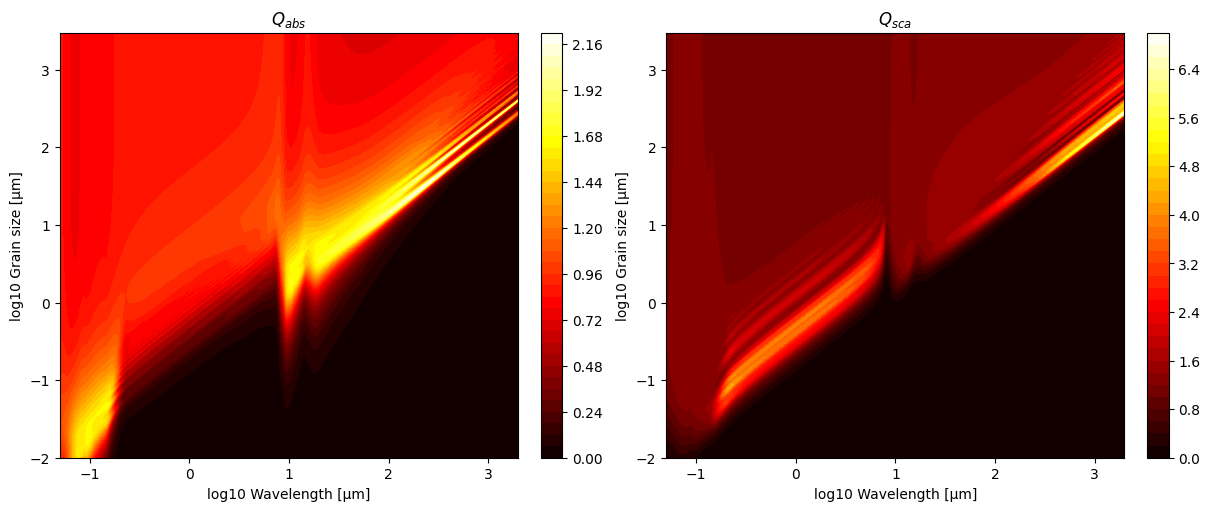

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

for ax, Q, title in zip(
    axes,
    [Q_abs, Q_sca],
    [r'$Q_{abs}$', r'$Q_{sca}$']
):
    im = ax.contourf(np.log10(waves), np.log10(sizes), Q, levels=15, cmap='hot')
    ax.set_xlabel('log10 Wavelength [µm]')
    ax.set_ylabel('log10 Grain size [µm]')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.show()

#### Alternatively, you can use the built-in helper:
```python
grain.plot_Q()  # optional bounds: min_wave, max_wave, min_size, max_size
```

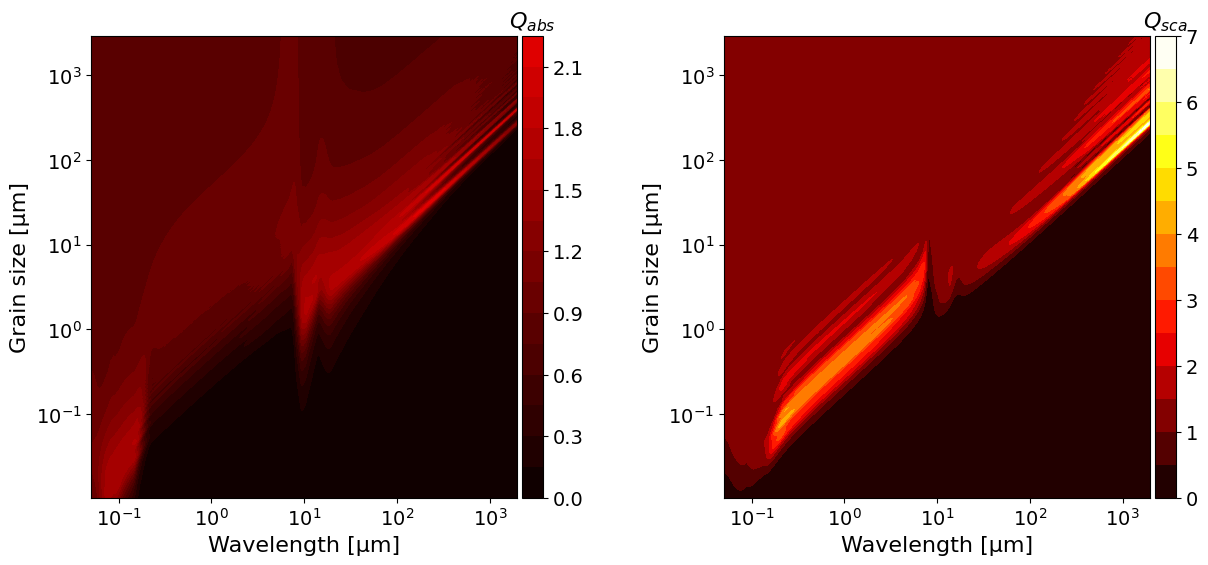

In [7]:
grain.plot_Q()

## 5. Materials and compositions
The composition name must exist in `data/material_list.txt`. Each entry defines optical and physical properties (e.g., sublimation temperature `Tsub`).

To explore available compositions:

In [ ]:
from pyGrater import utils as utl
from pyGrater.config.paths import DataPathConfig

data_path = DataPathConfig.get_data_path()        
materials_path = data_path / 'material_list.txt' 

mat_dict = utl.import_material_properties(materials_path)
print("Available compositions:")
print(list(mat_dict.keys()))


## 6. Recompute Q after changing parameters
If you adjust the grid (`N_sizes`, `N_waves`, ranges), or the composition, force recomputation:
```python
grain = stgr.Grain(redo_Q=True)
```
This will populate the `efficiencies/` directory for later fast loading.

## 7. Summary
- Use `Grain` to access precomputed `Q_abs` and `Q_sca` on a (size, wavelength) grid, or to compute them.
- Control grid density and ranges via `parameters/developper_params.yaml`
- Visualize 1D slices and 2D maps to understand scattering/absorption behavior
- Change composition in `Grain` and set `redo_Q=True` to update tables